## Import Library

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [52]:
df=pd.read_csv('instructor_effectiveness.csv')

In [53]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


## Now checking for NaN in the dataset

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


#### no column contain NaN value which is good for us

## Finding relationship between different variable

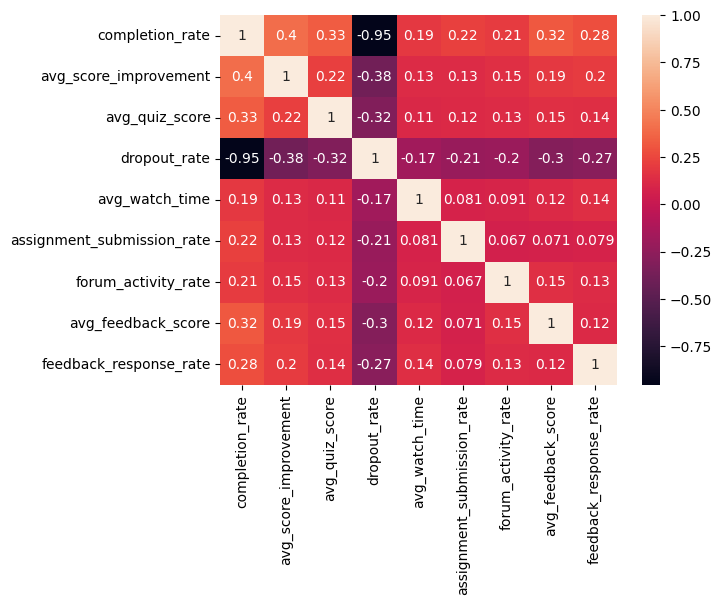

In [55]:
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

#### so from the heat map we can observe that completion_rate is inversly propotional to dropout_rate which is a obvious observation and completion rate is directly proportional to avg_score_improvement

In [56]:
instructor_df=df.groupby('instructor_id').agg({
    'completion_rate':'mean',
    'dropout_rate':'mean',
    'avg_score_improvement':'mean',
    'avg_quiz_score':'mean',
    'avg_watch_time':'mean',
    'assignment_submission_rate':'mean',
    'forum_activity_rate':'mean',
    'avg_feedback_score':'mean',
    'feedback_response_rate':'mean',
    'batch_id':'count'
})

In [57]:
instructor_df.rename(columns={'batch_id':'num_of_batches'},inplace=True) ##here inPlace =True means directly change into current data frame

In [58]:
instructor_df

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_of_batches
instructor_id,,,,,,,,,,
I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25
I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20
I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18
I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17
I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19
...,...,...,...,...,...,...,...,...,...,...
I_116,0.597106,0.412782,26.029714,78.640236,0.761489,0.660695,0.274891,4.091469,0.719787,17
I_117,0.691715,0.312481,28.430884,80.981607,0.793272,0.814243,0.265179,4.305839,0.713759,19
I_118,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,19


<Axes: >

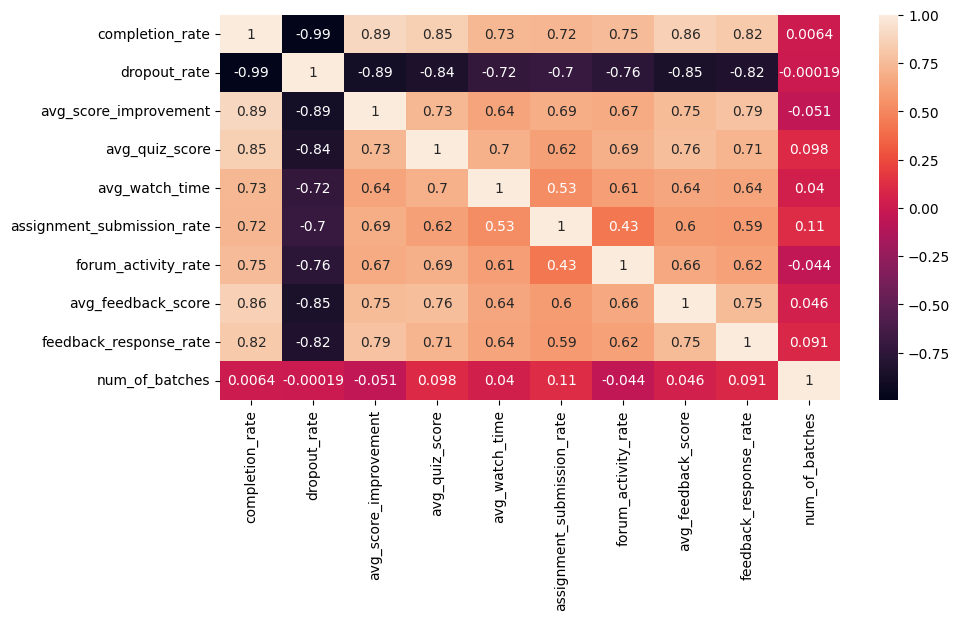

In [59]:
plt.figure(figsize=(10,5))
sns.heatmap(instructor_df.corr(),annot=True)

#### so from the above heatmap we can think that completion_rate is strongly directly proportional to student outcome and is strongly inversly proportional by dropout_rate

In [60]:
instructor_df['instructor_effectiveness'] = (
    0.30 * instructor_df['completion_rate'] +
    0.20 * (1 - instructor_df['dropout_rate']) +
    0.15 * (instructor_df['avg_score_improvement'] / 100) +
    0.15 * (instructor_df['avg_quiz_score'] / 100) +
    0.07 * instructor_df['avg_watch_time'] +
    0.05 * instructor_df['assignment_submission_rate'] +
    0.03 * instructor_df['forum_activity_rate'] +
    0.03 * (instructor_df['avg_feedback_score'] / 5) +
    0.02 * instructor_df['feedback_response_rate']
)

In [61]:
instructor_df

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_of_batches,instructor_effectiveness
instructor_id,,,,,,,,,,,
I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,0.563781
I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,0.685449
I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,0.699022
I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,0.518045
I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,0.760446
...,...,...,...,...,...,...,...,...,...,...,...
I_116,0.597106,0.412782,26.029714,78.640236,0.761489,0.660695,0.274891,4.091469,0.719787,17,0.587111
I_117,0.691715,0.312481,28.430884,80.981607,0.793272,0.814243,0.265179,4.305839,0.713759,19,0.653444
I_118,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,19,0.733962


In [62]:
(instructor_df['instructor_effectiveness']).max()


np.float64(0.8171880687833846)

In [63]:
instructor_df['instructor_effectiveness'].min()

np.float64(0.40762936731645266)

In [64]:
(instructor_df['instructor_effectiveness']>0.7).sum()

np.int64(15)

In [65]:
(instructor_df['instructor_effectiveness']>0.6).sum()

np.int64(56)

In [66]:
conditions=[
    (instructor_df['instructor_effectiveness']>0.7),
    (instructor_df['instructor_effectiveness']>0.6),
    (instructor_df['instructor_effectiveness']>0.4),
]
values=['High','Medium','Low']
instructor_df['instructor_tier']=np.select(conditions, values,default='')

In [67]:
instructor_df

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_of_batches,instructor_effectiveness,instructor_tier
instructor_id,,,,,,,,,,,,
I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,0.563781,Low
I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,0.685449,Medium
I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,0.699022,Medium
I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,0.518045,Low
I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,0.760446,High
...,...,...,...,...,...,...,...,...,...,...,...,...
I_116,0.597106,0.412782,26.029714,78.640236,0.761489,0.660695,0.274891,4.091469,0.719787,17,0.587111,Low
I_117,0.691715,0.312481,28.430884,80.981607,0.793272,0.814243,0.265179,4.305839,0.713759,19,0.653444,Medium
I_118,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,19,0.733962,High


## Now LabelEncoding the instructor_tier

#### we will use LabelEncoder here because our data is ordinal data where ranking matters

In [68]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
instructor_df.iloc[:, -1] = encoder.fit_transform(instructor_df.iloc[:, -1])

In [69]:
instructor_df

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_of_batches,instructor_effectiveness,instructor_tier
instructor_id,,,,,,,,,,,,
I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,0.563781,1
I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,0.685449,2
I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,0.699022,2
I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,0.518045,1
I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,0.760446,0
...,...,...,...,...,...,...,...,...,...,...,...,...
I_116,0.597106,0.412782,26.029714,78.640236,0.761489,0.660695,0.274891,4.091469,0.719787,17,0.587111,1
I_117,0.691715,0.312481,28.430884,80.981607,0.793272,0.814243,0.265179,4.305839,0.713759,19,0.653444,2
I_118,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,19,0.733962,0


In [70]:
instructor_df=instructor_df.reset_index()


In [71]:
instructor_df=instructor_df.drop(columns=['instructor_id','instructor_effectiveness'])

In [72]:
instructor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   completion_rate             120 non-null    float64
 1   dropout_rate                120 non-null    float64
 2   avg_score_improvement       120 non-null    float64
 3   avg_quiz_score              120 non-null    float64
 4   avg_watch_time              120 non-null    float64
 5   assignment_submission_rate  120 non-null    float64
 6   forum_activity_rate         120 non-null    float64
 7   avg_feedback_score          120 non-null    float64
 8   feedback_response_rate      120 non-null    float64
 9   num_of_batches              120 non-null    int64  
 10  instructor_tier             120 non-null    object 
dtypes: float64(9), int64(1), object(1)
memory usage: 10.4+ KB


In [73]:
instructor_df['instructor_tier'] = instructor_df['instructor_tier'].astype(int)

In [74]:
instructor_df

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_of_batches,instructor_tier
0,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,1
1,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,2
2,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,2
3,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,1
4,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,0
...,...,...,...,...,...,...,...,...,...,...,...
115,0.597106,0.412782,26.029714,78.640236,0.761489,0.660695,0.274891,4.091469,0.719787,17,1
116,0.691715,0.312481,28.430884,80.981607,0.793272,0.814243,0.265179,4.305839,0.713759,19,2
117,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,19,0
118,0.600597,0.399761,25.159349,80.735733,0.774830,0.766803,0.227028,4.315403,0.759761,19,1


## Spilting data into Training set and testing set

In [75]:
from sklearn.model_selection import train_test_split
X=instructor_df.iloc[:,0:-1].values
y=instructor_df.iloc[:,-1].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [76]:
y_test

array([1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 2, 2, 2, 1, 1, 0, 2, 1,
       1, 2])

## Applying a classification model that is DecisionTreeClassifier

In [77]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion='entropy',random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

### Checking the model Accuracy using confusion matrix and accuracy_score

In [78]:
from sklearn.metrics import confusion_matrix,accuracy_score
confusion_matrix(y_test,y_pred)

array([[ 3,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  8]])

In [79]:
accuracy_score(y_test,y_pred)

1.0

# Analysis Question

Q1.Which features most influenced instructor effectiveness, and why?

Answer1. So according to my analysis most important metrics is completion_rate if we have have high completion_rate then this means that instructor has high retention of student which means he is a good inscructor

Q2.Which variables could be misleading or confounded?

Answer2. assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate.These are some of the parameter through which you cannot predict anything and can be misleading in the analysis

Q3. How could this model fail in real-world usage?


Answer3. So if a instrcuctor is giving other benifits such as extra marks or very less fees then this model can be failed


Q4. 4.​ What additional data would you want to improve this analysis?

Answer 4. Direct rating by the student will be very helpfull,teaching experience would be a helpful parameter

Q5.​ Should this model be used for instructor performance evaluation? Why or why not?

Answer 5.Yes this model can be used in real world but should be first fined tunned and the model should have continous feedback program to constantly. If not maintained properly then it become of no use 